In [1]:
from pathlib import Path
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")

# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
logger.info(f"module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
else:
    logger.info("Module path already inserted into system paths")

try:
    from model import utils
    importlib.reload(utils)
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: module directory: /home/mohammad/projects/Thesis/hemophilia


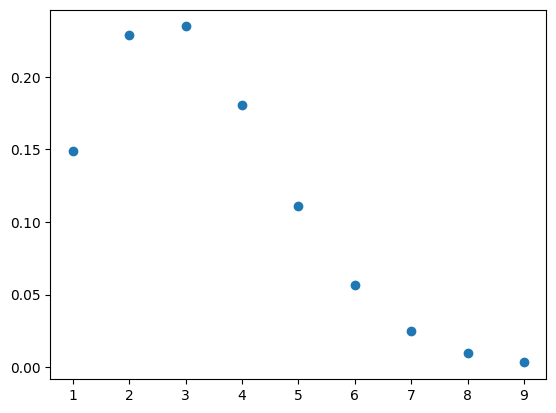

In [10]:
abr = 160
weeks_of_years = 52
frequency_given_interval = abr / weeks_of_years
values = {}
for i in range(10):
    if i == 0:
        continue
    values[i] = utils.zero_truncated_mass_function(lam=frequency_given_interval, k=i)
    
import matplotlib.pyplot as plt
plt.scatter(values.keys(), values.values()) # type: ignore